# Pipeline 4: Donor Lifetime Value (LTV) Proxy

**Organization:** River of Life / Lighthouse Sanctuary (INTEX)  
**Methodology:** CRISP-DM–aligned (see `pipeline_guide.md` in this folder)

---

## Executive Summary

We estimate **monetary giving over the next 365 days** from each supporter’s history—a **practical LTV proxy** when true lifetime length is unknown.

**What this notebook delivers**
- 365-day forward sum as operational target
- Dummy + Ridge + Random Forest compared with grouped CV
- PostgreSQL store for portfolio views in .NET

*Non-technical readers:* skim the Executive Summary, **Business Interpretation**, **Key Findings**, and **Recommended Actions**, then use charts in Sections 3–5 for discussion with data staff.

---


## 1. Problem Framing

### Business problem
Leadership needs a **forward-looking donor value** view for staffing and campaign investment—not only last gift.

### Stakeholders
| **ED / board** | Portfolio narrative |
| **Major gifts** | Pipeline depth |
| **Finance** | Rough receipts (scenario only) |

### Why this matters
Concentrating relationship time on **high forward-value** donors (with ethics) improves ROI of scarce staff hours.

### Predictive goal (what we forecast or score)
**Regression:** predicted **sum of monetary gifts** in the next 365 days (log1p trained).

### Explanatory goal (what we want to understand)
**Ridge** shows which historical patterns align with **higher forward-year totals**.

### Why predictive and explanatory are different
Trees may fit nonlinear combos for **scoring**; Ridge supports **storytelling** in board decks.

### Decision this work supports
**Portfolio tiers** and **relationship manager assignment** priorities.

### Limitations (preview)
One-year window ≠ lifetime; macro shocks omitted.

---


## Data Validity & Leakage Check

### How the target is defined
**y** = sum of `amount` for monetary gifts with `as_of` < date ≤ `as_of + 365 days`.

### What information is allowed at prediction time
Gifts and allocations strictly before `as_of`; static supporter attributes.

### Why future information does not leak into features
Forward-year gifts excluded from features.

### Why the train/test approach is valid
**GroupKFold / GroupShuffleSplit** by `supporter_id`.

### Automated checks in this notebook
Panel date bounds printed with row counts.

---


## 2. Data Acquisition & Preparation

**Tables:** monetary `donations`, `supporters`, `donation_allocations` for program count.

Same engineering patterns as Pipeline 3 with **365-day horizon**.

---


In [6]:
import json
import warnings
from datetime import timedelta
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns  # noqa: F401 — used in EDA cells across generated notebooks

warnings.filterwarnings("ignore", category=UserWarning)
RANDOM_STATE = 42
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("talk", font_scale=0.85)

def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / "lighthouse_csv_v7").is_dir():
            return p
    raise FileNotFoundError(
        "Could not find lighthouse_csv_v7. Open or run from the INTEX II EDA project folder."
    )

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "lighthouse_csv_v7"
OUTPUT_DIR = PROJECT_ROOT / "ml_pipelines" / "artifacts"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("PROJECT_ROOT:", PROJECT_ROOT.resolve())


PROJECT_ROOT: /Users/jaxon/Documents/BYU Archive/Winter 2026 - Junior Core IS/INTEX II/INTEX II EDA


In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

def ws(s):
    return s.clip(s.quantile(0.01), s.quantile(0.99))

sup = pd.read_csv(DATA_DIR / "supporters.csv", parse_dates=["created_at"])
mon = pd.read_csv(DATA_DIR / "donations.csv", parse_dates=["donation_date"])
mon = mon[(mon["donation_type"] == "Monetary") & mon["amount"].notna()].copy()
alloc = pd.read_csv(DATA_DIR / "donation_allocations.csv")
da = mon.merge(alloc, on="donation_id", how="left")
rows = []
anchors = pd.date_range("2023-04-01", "2025-01-01", freq="MS")
mx = mon["donation_date"].max()
for as_of in anchors:
    if as_of + timedelta(days=365) > mx:
        continue
    for sid in mon.loc[mon["donation_date"] < as_of, "supporter_id"].unique():
        pm = mon[(mon["supporter_id"] == sid) & (mon["donation_date"] < as_of)]
        if pm.empty:
            continue
        fut = mon[(mon["supporter_id"] == sid) & (mon["donation_date"] > as_of) & (mon["donation_date"] <= as_of + timedelta(days=365))]
        y = float(fut["amount"].sum())
        last = pm.sort_values("donation_date").iloc[-1]
        rec = (as_of - last["donation_date"]).days
        freq = len(pm)
        sm = ws(pm["amount"]).sum()
        mn = pm["amount"].mean()
        hr = int(pm["is_recurring"].fillna(False).astype(bool).any())
        ten = (as_of - pm["donation_date"].min()).days
        npr = int(da[(da["supporter_id"] == sid) & (da["donation_date"] < as_of)]["program_area"].nunique(dropna=True))
        rows.append({"supporter_id": sid, "as_of": as_of, "y_ltv": y, "recency_days": rec, "frequency": freq, "hist_sum": sm, "hist_mean": mn, "has_recurring": hr, "tenure_days": ten, "n_prog": npr})
p = pd.merge(pd.DataFrame(rows), sup[["supporter_id", "supporter_type", "region", "acquisition_channel"]], on="supporter_id")
p["log1p_y"] = np.log1p(p["y_ltv"])
print(p.shape, p["y_ltv"].describe())
NUM = ["recency_days", "frequency", "hist_sum", "hist_mean", "has_recurring", "tenure_days", "n_prog"]
CAT = ["supporter_type", "region", "acquisition_channel"]
X, y, g = p[NUM + CAT], p["log1p_y"], p["supporter_id"]
prep = ColumnTransformer([("n", StandardScaler(), NUM), ("c", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT)])

def pipe(m):
    return Pipeline([("p", prep), ("m", m)])


(779, 14) count      779.000000
mean      1526.082362
std       1839.315296
min          0.000000
25%          0.000000
50%       1032.040000
75%       2223.050000
max      11420.850000
Name: y_ltv, dtype: float64


## 3. Exploration (EDA)

We visualize distributions and relationships **relevant to the business question**, not generic plots. Narrative interpretation follows each chart in markdown where noted.

---


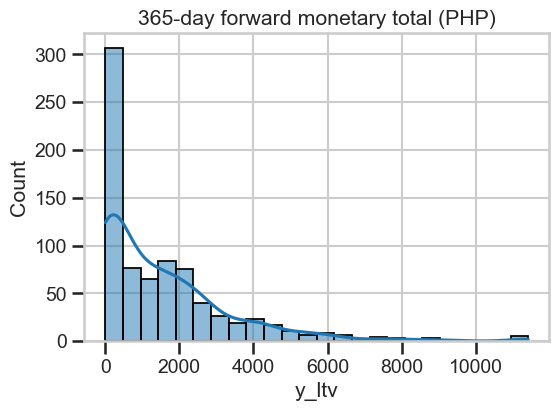

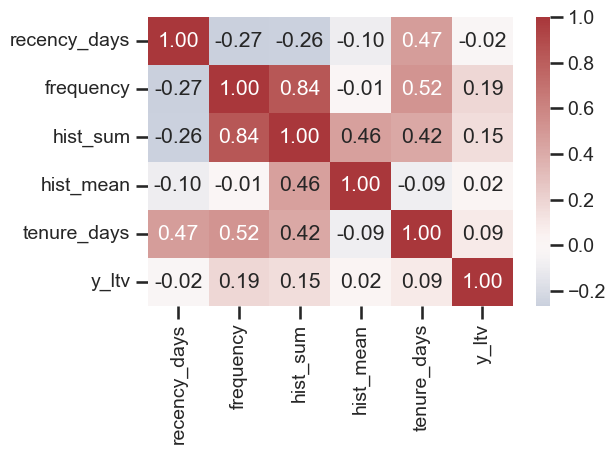

In [8]:
plt.figure(figsize=(6, 4))
sns.histplot(p["y_ltv"], kde=True)
plt.title("365-day forward monetary total (PHP)")
plt.show()
sns.heatmap(p[["recency_days", "frequency", "hist_sum", "hist_mean", "tenure_days", "y_ltv"]].corr(), annot=True, fmt=".2f", cmap="vlag", center=0)
plt.tight_layout()
plt.show()


## 4. Modeling & Feature Selection

### Feature rationale (why these inputs)
RFM + recurring + program count proxy **breadth of mission engagement**.

### Three-model strategy
1. **Baseline — Mean log1p forward total:** trivial rule so we never mistake “model” for “signal.”
2. **Interpretable — Ridge regression:** coefficients or clear structure for **explanation** and stakeholder trust.
3. **Performance — Random Forest (+ GBRT in CV loop):** stronger fit for **batch scoring**; may sacrifice some interpretability.

### Feature selection
We keep the feature set **parsimonious** and justified; where helpful, regularization (Ridge / L1) or tree-based implicit selection reduces noise. Final model choice is documented in Section 5 with **tradeoffs**.

---


baseline RMSE_log 3.474991334194725 R2 -0.22816993660117676
ridge RMSE_log 3.743622267063654 R2 -0.5332820264468909
rf RMSE_log 3.7274192326954547 R2 -0.4315041175120813
gbrt RMSE_log 3.7675923757954095 R2 -0.4669005272541179
Holdout MAE pesos 1516.2670504913458


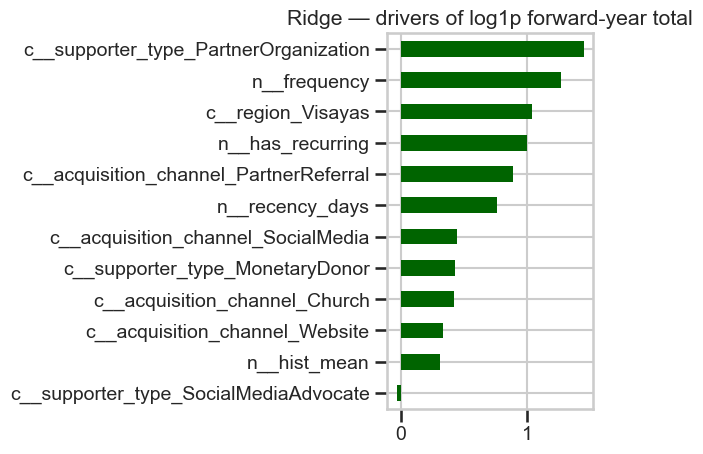

In [9]:
gkf = GroupKFold(5)
for name, m in [("baseline", DummyRegressor(strategy="mean")), ("ridge", Ridge(3.0)), ("rf", RandomForestRegressor(200, max_depth=6, min_samples_leaf=4, random_state=RANDOM_STATE, n_jobs=-1)), ("gbrt", GradientBoostingRegressor(random_state=RANDOM_STATE, max_depth=3, n_estimators=120))]:
    sc = cross_validate(pipe(m), X, y, cv=gkf, groups=g, scoring={"rmse": "neg_root_mean_squared_error", "r2": "r2"}, n_jobs=-1)
    print(name, "RMSE_log", -sc["test_rmse"].mean(), "R2", sc["test_r2"].mean())
gss = GroupShuffleSplit(1, test_size=0.25, random_state=RANDOM_STATE)
tr, te = next(gss.split(X, y, g))
rf = RandomForestRegressor(220, max_depth=6, min_samples_leaf=4, random_state=RANDOM_STATE, n_jobs=-1)
pr = pipe(rf)
pr.fit(X.iloc[tr], y.iloc[tr])
pred = np.expm1(pr.predict(X.iloc[te]))
true = np.expm1(y.iloc[te])
print("Holdout MAE pesos", mean_absolute_error(true, pred))
ridge_explain = pipe(Ridge(3.0))
ridge_explain.fit(X.iloc[tr], y.iloc[tr])
coef = pd.Series(ridge_explain.named_steps["m"].coef_, index=ridge_explain.named_steps["p"].get_feature_names_out()).sort_values()
coef.tail(12).plot(kind="barh", color="darkgreen")
plt.title("Ridge — drivers of log1p forward-year total")
plt.tight_layout()
plt.show()


## 5. Evaluation & Interpretation

### Metrics
We report metrics appropriate to the task (regression: MAE, RMSE, R²; classification: accuracy, precision, recall, F1, ROC-AUC where applicable). **Grouped or held-out units** (donor, resident, safehouse) avoid optimistic scores when the same entity appears many times.

### What to look for
- **Lift over baseline:** if the interpretable and performance models barely beat the baseline, treat outputs as **weak decision support** until more data arrives.
- **Stability:** cross-validation spread indicates whether the model generalizes or chases noise.

---


## Business Interpretation

### What this means in plain English
Higher predicted **next-year totals** mean “this relationship likely moves more money soon”—not that the person is ‘better.’

### How reliable is this for real decisions?
Use for **ranking** inside portfolio reviews; external audit of fairness recommended if used in HR-like decisions.

### What should the organization do differently?
Pair tiers with **qualitative relationship knowledge**; do not auto-cut stewardship for ‘low LTV’ scores.

### What decision does this directly support?
**Time allocation** for major-gift officers and **board charts**.

### When the model is wrong
- **False positives (predicted high risk / high amount / etc., but reality was “fine”):**  
  Over-invest time on someone who quiets giving → opportunity cost.
- **False negatives (model said “low concern” but something important happened):**  
  Under-invest in a rising donor → missed relationship; mitigate with **floor touches** for all active donors.

---


## 6. Causal & Relationship Analysis

### What relationships showed up in the data
Past heavy givers tend to show higher forward sums in-sample.

### Why these are not proven causal
Wealth, channel, and life events confound.

### Honest limitations
Single synthetic org sample; short history.

---


## Key Findings

- Compare every release to **baseline mean**.
- Ridge gives **narrative**; RF gives **scores**.
- 365d sum is a **proxy**, not philosophical lifetime value.

---


## Recommended Actions

- Publish **tier definitions** internally (deciles).
- Refresh after **major campaigns**.
- Document **ethical use** policy (no automated donor shaming).

---


## 7. Deployment Plan

### What triggers scoring
**Monthly batch** after books close or weekly if CRM supports incremental sync.

### Where results appear in the .NET application
**Development dashboard** → Donor portfolio heatmap; export for board slides (aggregated only).

### Who uses the output and how
| **Leadership** | Strategy |
| **MGO** | Call lists |

### PostgreSQL table schema

```sql
CREATE TABLE donor_ltv_estimates (
  id BIGSERIAL PRIMARY KEY,
  supporter_id INTEGER NOT NULL,
  as_of_date DATE NOT NULL,
  horizon_days INTEGER NOT NULL DEFAULT 365,
  estimated_forward_giving_php DOUBLE PRECISION NOT NULL,
  tier VARCHAR(16),
  model_version VARCHAR(40) NOT NULL,
  scored_at TIMESTAMPTZ NOT NULL DEFAULT NOW(),
  UNIQUE (supporter_id, as_of_date, horizon_days, model_version)
);
```

### Example upsert (batch job after training/scoring)

```sql
INSERT INTO donor_ltv_estimates (supporter_id, as_of_date, horizon_days, estimated_forward_giving_php, tier, model_version)
VALUES (42, DATE '2026-04-07', 365, 15000.0, 'TierA', 'ltv_v2')
ON CONFLICT (supporter_id, as_of_date, horizon_days, model_version)
DO UPDATE SET estimated_forward_giving_php = EXCLUDED.estimated_forward_giving_php, tier = EXCLUDED.tier, scored_at = NOW();
```

### Python → PostgreSQL → .NET data flow
1. Scheduled **batch job** (e.g., nightly Airflow / Azure Function / Windows Task Scheduler) runs this notebook’s scoring script or a `joblib` loader.
2. Script reads the latest warehouse export or DB replica, builds features **as of `run_date`**, computes predictions.
3. Results are **UPSERTed** into the table below (idempotent per natural key).
4. The **.NET** admin API reads via EF Core or Dapper; UI shows sortable lists, filters, and **no raw model internals** to end users unless “explain” panel is explicitly designed.

Scoring job: `joblib.load` → compute features as-of run date → upsert.

---


In [10]:
from joblib import dump
final = pipe(RandomForestRegressor(220, max_depth=6, min_samples_leaf=4, random_state=RANDOM_STATE, n_jobs=-1))
final.fit(X, y)
dump(final, OUTPUT_DIR / "donor_ltv_v2.joblib")
print("Saved artifact")


Saved artifact
